# Model Fitting and Hough Transforms

In this notebook, we'll cover how to fit a model to data. We'll use the example of fitting a line to a set of points in 2D space. We'll also cover how to use the Hough transform to fit lines to edges in an image.

Let's generate a simple binary image with a line and a circle in it and then detect its edges.

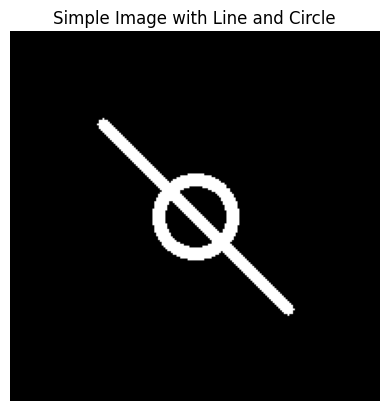

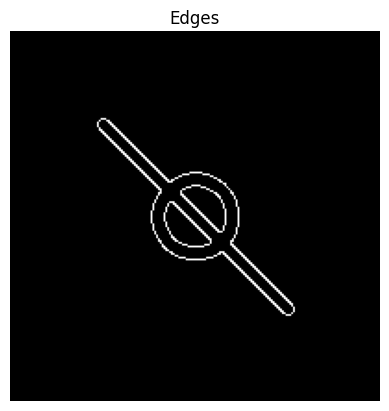

In [1]:
# Import required libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Function to display images
def display_image(img, title="Image"):
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Create a simple image with a white line and a white circle on a black background
height, width = 200, 200
simple_image = np.zeros((height, width), dtype=np.uint8)

# Draw a white line from (50, 50) to (150, 150)
cv2.line(simple_image, (50, 50), (150, 150), 255, 5)

# Draw a white circle centered at (100, 100) with a radius of 20
cv2.circle(simple_image, (100, 100), 20, 255, 5)

display_image(simple_image, "Simple Image with Line and Circle")

# Apply edge detection
edges = cv2.Canny(simple_image, 100, 200)

display_image(edges, "Edges")

## Understanding Hough Voting Scheme
(For teaching purposes, not an optimized way to do it)

In the following we show how the Hough voting scheme works by using the simple edge image generated above. We will use the edge image to detect the straight lines in the image.

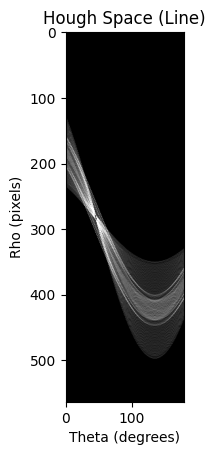

In [2]:
# ----------- Understanding Hough Voting Scheme -----------
# Hough Space for lines
# (For teaching purposes, not an optimized way to do it)

# Initialize theta range and its sine and cosine values
theta_range = np.deg2rad(np.arange(-90.0, 90.0))
cos_theta, sin_theta = np.cos(theta_range), np.sin(theta_range)

# Initialize the accumulator
# Max possible distance is the diagonal length of the image. We double it to account for negative rhos.
max_dist = int(np.sqrt(height**2 + width**2))
accumulator = np.zeros((2 * max_dist, len(theta_range)), dtype=np.uint64)

# Loop through edge points and update the accumulator
for y in range(height):
    for x in range(width):
        if edges[y, x] != 255:
            continue
        rho_values = x * cos_theta + y * sin_theta
        accumulator[np.round(rho_values + max_dist).astype(int),
                    np.arange(len(theta_range))] += 1

# Display the accumulator
plt.imshow(accumulator, cmap='gray', vmin=0, vmax=20)
plt.title('Hough Space (Line)')
plt.xlabel('Theta (degrees)')  # Now it's in degrees ranging from 0 to 180
plt.ylabel('Rho (pixels)')
plt.show()


From the accumulator matrix, we will find the maximum value and its location. The location will give us the parameters of the line detected.

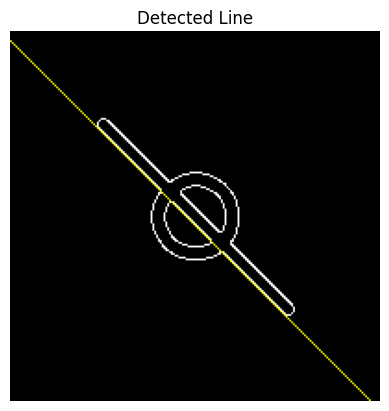

In [3]:
# Show the strongest detected line on the edge image

# Find the maximum value in the accumulator
rho_idx, theta_idx = np.unravel_index(np.argmax(accumulator), accumulator.shape)
rho = rho_idx - max_dist
theta = theta_range[theta_idx]

# Create a copy of the original image and convert it to RGB
line_img = cv2.cvtColor(edges.copy(), cv2.COLOR_GRAY2RGB)

a, b = np.cos(theta), np.sin(theta)
x0, y0 = a * rho, b * rho
x1, y1 = int(x0 + 1000 * (-b)), int(y0 + 1000 * (a))
x2, y2 = int(x0 - 1000 * (-b)), int(y0 - 1000 * (a))
cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 255), 1)

display_image(line_img, "Detected Line")


## Using OpenCV's Hough Transform

The function call `cv2.HoughLines(edges, 1, np.pi / 180, 50)` uses the Hough Line Transform to find lines within an image. Here is a description of each of its parameters:

1. **`edges`**: This is the input image, typically a binary image where edges are marked with white pixels (usually the output of an edge detection algorithm like the Canny edge detector).

2. **`1`**: This is the resolution of the accumulator in terms of the radius `ρ` (Rho). The unit is in pixels. A smaller value will generally detect more lines but may be more computationally intensive. A value of `1` means that each bin in the accumulator matrix will represent one pixel unit for the `ρ` (Rho) value.

3. **`np.pi / 180`**: This is the angle resolution of the accumulator in radians. In this case, `np.pi / 180` corresponds to one degree. The parameter determines the angular resolution with which the algorithm will search for lines. A smaller value will result in more lines being detected, but computation might become more intensive.

4. **`80`**: This is the threshold parameter. Only those lines that get a number of votes in the accumulator greater than this value are returned. Basically, this parameter sets the minimum number of intersections needed to detect a line.

These parameters allow you to control the sensitivity and specificity of the line detection algorithm to fit your specific needs.

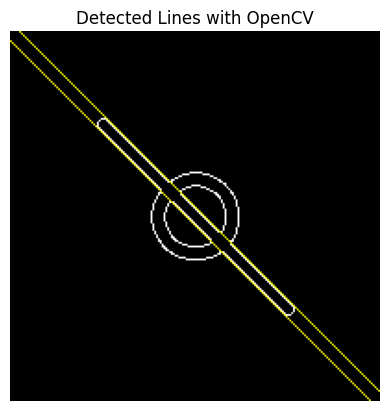

In [4]:
# ----------- Using OpenCV's Hough Transform -----------
# Hough Lines
lines = cv2.HoughLines(edges, 1, np.pi / 180, 80)

# Create a copy of the original image and convert it to RGB
line_img = cv2.cvtColor(edges.copy(), cv2.COLOR_GRAY2RGB)

# Check if any line is detected
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho
        x1, y1 = int(x0 + 1000 * (-b)), int(y0 + 1000 * (a))
        x2, y2 = int(x0 - 1000 * (-b)), int(y0 - 1000 * (a))
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 255), 1)

display_image(line_img, "Detected Lines with OpenCV")

### How to draw the lines?

The output of the Hough Line Transform is a list of points in the parameter space `(ρ, θ)` which corresponds to the detected lines. The `ρ` and `θ` values of these points are computed using the `cv2.HoughLines()` function. 

- **`rho, theta = line[0]`:** For each line detected, `rho` is the distance from the origin (top-left corner of the image), and `theta` is the angle.
- **`a, b = np.cos(theta), np.sin(theta)`:** Calculate the cos and sin values for the angle.
- **`x0, y0 = a * rho, b * rho`:** Calculate a point (x0, y0) that lies on the line. This is used as an anchor point to draw the line.
- **`x1, y1` and `x2, y2`:** These are two points far away on the line from the anchor point. By drawing a line through these two points, we effectively draw the detected line.
- **`cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 255), 1)`:** Draw the line on `line_img`.

The line is drawn in yellow `(0, 255, 255)` with a thickness of `1`.

The numbers `1000` and `-1000` are essentially used to find points that are far enough along the line from the anchor point `(x0, y0)`, ensuring that the line extends across the entire image.

## Hough circles

The OpenCV function `cv2.HoughCircles` implements the Hough transform for circles. It returns the `(x, y)` coordinates of the circle's center and its radius.

**Note the input image.** `cv2.HoughLines` wants the binary edge map, because it treats every nonzero pixel as a voter and does no edge detection of its own. `cv2.HoughCircles` is the opposite: with `cv2.HOUGH_GRADIENT` it runs Canny internally (that is what `param1` is for) and then uses the *gradient direction* at each edge pixel to decide which centers to vote for. Passing it an already-binarized edge map throws away the gradient information it depends on. Neither function raises an error when given the wrong one; they just return a different answer. On the image below, passing `edges` reports a radius of 22.7 pixels and passing `simple_image` reports 16.7.

Here is what each parameter does:

1. **`simple_image`**: the 8-bit, single-channel **grayscale** source image, *not* an edge map.

2. **`cv2.HOUGH_GRADIENT`**: the detection method. OpenCV 4.3 and later also offer `cv2.HOUGH_GRADIENT_ALT`, which is more accurate; see the comparison below.

3. **`dp=1`**: The inverse ratio of the accumulator resolution to the image resolution. For example, if `dp=1`, the accumulator has the same resolution as the input image. If `dp=2`, the accumulator has half as big width and height.

4. **`minDist=10`**: The minimum distance between the centers of detected circles. If the distance is smaller than this, the algorithm will merge such circles. The value is in pixels.

5. **`param1=100`**: The higher threshold for the internal Canny edge detector. The lower threshold is automatically set to half of this value (`param1/2`).

6. **`param2=15`**: The threshold for the circle accumulator. The accumulator value for each possible circle is compared against this threshold. Circles that have an accumulator value greater than `param2` will be returned. Lower values will detect more circles but can result in more false positives.

7. **`minRadius=15`**: Minimum circle radius, in pixels. This parameter helps to filter out smaller circle-like objects that you are not interested in.

8. **`maxRadius=30`**: Maximum circle radius, in pixels. This parameter helps to filter out larger circle-like objects that you are not interested in.

These parameters collectively allow you to fine-tune the circle detection process according to your specific needs.

HOUGH_GRADIENT: [[100 100  17]]


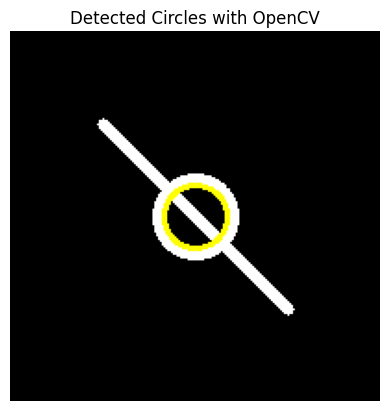

In [5]:
# Hough Circles
# NOTE: the input is the grayscale image, not `edges`.
# HOUGH_GRADIENT runs Canny itself and needs gradient
# directions, which a binary edge map no longer has.
circles = cv2.HoughCircles(simple_image, cv2.HOUGH_GRADIENT,
                           dp=1, minDist=10,
                           param1=100, param2=15,
                           minRadius=15, maxRadius=30)

# Convert to a color image for visualization
circle_img = cv2.cvtColor(simple_image.copy(), cv2.COLOR_GRAY2RGB)

# Check if any circle is detected
if circles is not None:
    # Round the (x, y) coordinates and radius of the circles
    circles = np.round(circles[0, :]).astype("int")

    # Loop over the circles to draw them
    for (x, y, r) in circles:
        cv2.circle(circle_img, (x, y), r, (0, 255, 255), 2)

    print("HOUGH_GRADIENT:", circles)

# Display image
display_image(circle_img, "Detected Circles with OpenCV")

We drew the circle with radius 20 and thickness 5, so the white ring runs from radius 17.5 to 22.5. `HOUGH_GRADIENT` puts the center within half a pixel of (100, 100), but reports a radius of about 16.7: a thick ring has two concentric edges, and the method settles near the inner one.

Lowering `minDist` does not recover "the other circle". There is only one circle in the image. What a smaller `minDist` gives you is a cluster of near-duplicate detections of the same ring, which is the same non-maximum suppression problem you saw with lines.

The radius estimate is what `cv2.HOUGH_GRADIENT_ALT` improves. It was added in OpenCV 4.3 and uses a different accumulator, so `param2` changes meaning: instead of a vote count it is a 0 to 1 score for how circle-like the candidate is, and 0.8 to 0.9 is a sensible starting range.

HOUGH_GRADIENT_ALT: [[102.  99.  21.]]


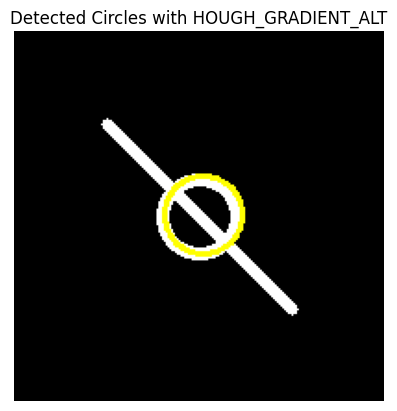

In [6]:
# The newer method, for comparison. Note that param2 now means something else:
# a 0 to 1 "perfectness" score rather than a vote count.
circles_alt = cv2.HoughCircles(simple_image, cv2.HOUGH_GRADIENT_ALT, dp=1.5,
                               minDist=10, param1=300, param2=0.8,
                               minRadius=10, maxRadius=30)

alt_img = cv2.cvtColor(simple_image.copy(), cv2.COLOR_GRAY2RGB)
if circles_alt is not None:
    for (x, y, r) in np.round(circles_alt[0, :]).astype("int"):
        cv2.circle(alt_img, (x, y), r, (0, 255, 255), 2)
    print("HOUGH_GRADIENT_ALT:", np.round(circles_alt[0, :], 1))

display_image(alt_img, "Detected Circles with HOUGH_GRADIENT_ALT")